# Strait of Hormuz (SoH) Crossing Tracker

Programmatic view of Mid-East Gulf (MEG) entries/exits from Kpler-style crossing history,
enriched with AFRA vessel-class mapping and OFAC sanction flags.

**Questions this notebook answers**
1. Which vessels exited / entered in period X?
2. How much crude / products left? How many tankers entered since X and are *likely still inside*?
3. Which vessels crossed the SoH most frequently in a range?
4. What is the **dark fleet** doing vs the **clean fleet**?

**Dark vs clean (working definition)**
- *Dark fleet*: OFAC-sanctioned vessels (Iran-program list primary; broader SDN vessel list also flagged).
- *Clean fleet*: vessels not on those OFAC lists.
- *Dark/Unknown Route*: a separate **route** attribute (`Crossing Type`). It is *not* what we mean by dark fleet — though we still report route mix, including how often each fleet uses dark routes.

**Cargo inference**
Not every laden row has a cargo tag. We keep those rows and, when AFRA class is VLCC/ULCC,
infer `likely_crude`; otherwise leave as `unknown`.


## 1. Setup & config

Change `START_DATE` / `END_DATE` (and optional `AS_OF`) to re-run all period questions.

In [1]:
from pathlib import Path
from datetime import date, timedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 140)

# Analysis charts: muted, high-contrast palette (avoid default purple glow look).
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

BASE = Path(r"C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing")

CROSSING_PATH = BASE / "soh_crossing_hist.xlsx"
AFRA_PATH = BASE / "afra_scale_mapping.xlsx"
OFAC_IRAN_PATH = BASE / "ofac_iran_vessels_history.csv"
OFAC_SDN_PATH = BASE / "ofac_sdn_vessels_2026-07-13.csv"

# --- Period filters (edit these) ---
# Example: since 17 Jun 2026 through latest data in the file
START_DATE = date(2026, 6, 17)
END_DATE = None  # None = no upper bound (use full history end)

# "Likely still inside" is evaluated as of this date (defaults to max crossing date in data)
AS_OF = None

# Frequent-crosser threshold
MIN_CROSSINGS = 2

## 2. Load & clean

In [2]:
def parse_dmy(series: pd.Series) -> pd.Series:
    """Crossing dates arrive as DD/MM/YYYY strings; dayfirst avoids US ambiguity."""
    return pd.to_datetime(series, dayfirst=True, errors="coerce")


def to_number(series: pd.Series) -> pd.Series:
    """Quantities/DWT often have thousand separators."""
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )


raw = pd.read_excel(CROSSING_PATH, sheet_name="SoH Crossing")
afra = pd.read_excel(AFRA_PATH)
ofac_iran = pd.read_csv(OFAC_IRAN_PATH)
ofac_sdn = pd.read_csv(OFAC_SDN_PATH)

crossings = raw.copy()
crossings["Crossing Date"] = parse_dmy(crossings["Crossing Date"])
crossings["IMO"] = pd.to_numeric(crossings["IMO"], errors="coerce").astype("Int64")
crossings["Quantity"] = to_number(crossings["Quantity"]).fillna(0.0)
crossings["Deadweight"] = to_number(crossings["Deadweight"])
# AFRA table is in thousand DWT (kdwt); convert once for joining.
crossings["dwt_kdwt"] = crossings["Deadweight"] / 1000.0

print(f"Rows: {len(crossings):,}")
print(
    f"Date range: {crossings['Crossing Date'].min().date()} → {crossings['Crossing Date'].max().date()}"
)
print(f"Unique IMOs: {crossings['IMO'].nunique():,}")
crossings.head(3)

Rows: 2,895
Date range: 2026-02-01 → 2026-08-11
Unique IMOs: 1,220


,Vessel Name,IMO,Vessel Classification,Flag Name,Direction,Crossing Date,Crossing Type,Loading State,Cargo Type,Quantity,Quantity Unit,Last Cargo Zone,Last Cargo Country,Next Port,Next Port Country,Deadweight,Build Year,Build Country,dwt_kdwt
0,BLACK MAYA,9118800,Small Tankers,CURACAO,Entered MEG,2026-08-11,Iranian Route,Ballast,NaN,0,bbl,Muscat,Oman,Khor Al Zubair Port,Iraq,2005,"1,995",JAPAN,2.005
1,NEW FUTURE,9379313,MR,MARSHALL ISLANDS,Entered MEG,2026-08-11,Iranian Route,Ballast,NaN,0,bbl,Fujairah,United Arab Emirates,Hamriya,United Arab Emirates,50922,"2,007",REPUBLIC OF KOREA,50.922
2,ABU DHABI III,9489027,Aframax/LR2,LIBERIA,Entered MEG,2026-08-10,Dark/Unknown Route,Ballast,NaN,0,bbl,Yantai,China,Ras Laffan,Qatar,105131,"2,011",REPUBLIC OF KOREA,105.131


## 3. AFRA class + cargo inference + OFAC flags

In [3]:
def map_afra_class(dwt_kdwt: float, afra_table: pd.DataFrame) -> str | None:
    """Map kdwt into AFRA bands. Upper bound inclusive; last band catches overflow."""
    if pd.isna(dwt_kdwt):
        return None
    for _, row in afra_table.sort_values("capacity_lower_bound").iterrows():
        lo, hi = row["capacity_lower_bound"], row["capacity_upper_bound"]
        if lo <= dwt_kdwt <= hi:
            return row["vessel_class"]
    # Below GP floor or above ULCC ceiling — still label extremes for filtering.
    if dwt_kdwt < afra_table["capacity_lower_bound"].min():
        return "Below GP"
    return "Above ULCC"


PRODUCT_TAGS = {"CPP", "DPP", "Chemicals", "Methanol", "Chemicals, Methanol"}
CRUDE_TAGS = {"Crude/Co"}
CRUDE_LIKE_CLASSES = {"VLCC", "ULCC", "Above ULCC"}


def infer_cargo(row: pd.Series) -> tuple[str, str]:
    """
    Returns (cargo_group, cargo_source).
    Keep untagged laden rows; only infer crude for VLCC/ULCC-class hulls.
    """
    loading = row["Loading State"]
    tag = row["Cargo Type"]
    vclass = row["afra_class"]

    if loading == "Ballast":
        return "ballast", "loading_state"

    if pd.notna(tag):
        if tag in CRUDE_TAGS:
            return "crude", "tagged"
        if tag in PRODUCT_TAGS:
            return "products", "tagged"
        return "other", "tagged"

    # Laden (or other) with no product tag — do not drop; infer when size implies crude.
    if vclass in CRUDE_LIKE_CLASSES:
        return "likely_crude", "inferred_afra"
    return "unknown", "untagged"


crossings["afra_class"] = crossings["dwt_kdwt"].map(lambda x: map_afra_class(x, afra))

cargo_info = crossings.apply(infer_cargo, axis=1, result_type="expand")
cargo_info.columns = ["cargo_group", "cargo_source"]
crossings = pd.concat([crossings, cargo_info], axis=1)

# Volume only counts when laden and group is crude/products (incl. inferred crude).
VOLUME_GROUPS = {"crude", "likely_crude", "products"}
crossings["volume_bbl"] = np.where(
    crossings["cargo_group"].isin(VOLUME_GROUPS),
    crossings["Quantity"],
    0.0,
)

In [4]:
def normalize_imo(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").astype("Int64")


# Dark fleet = sanctioned hulls. Iran-program list is the core signal; SDN catches a few extras.
iran_imos = set(normalize_imo(ofac_iran["imo"]).dropna().astype(int))
sdn_imos = set(normalize_imo(ofac_sdn["imo"]).dropna().astype(int))
sdn_iran_imos = set(
    normalize_imo(ofac_sdn.loc[ofac_sdn["iran_classification"] == "iran_specific", "imo"])
    .dropna()
    .astype(int)
)

crossings["sanctioned_iran"] = crossings["IMO"].isin(iran_imos)
crossings["sanctioned_sdn"] = crossings["IMO"].isin(sdn_imos)
crossings["sanctioned_any"] = crossings["sanctioned_iran"] | crossings["sanctioned_sdn"]

# Route opacity is tracked separately — do not conflate with dark fleet.
crossings["is_dark_route"] = crossings["Crossing Type"].eq("Dark/Unknown Route")

# Dark fleet <=> sanctioned; clean fleet <=> not sanctioned.
crossings["is_dark_fleet"] = crossings["sanctioned_any"]
crossings["fleet"] = np.where(crossings["is_dark_fleet"], "dark fleet", "clean fleet")

print("Sanction / dark-fleet overlap with crossings")
print(f"  Iran-list IMOs in file: {crossings.loc[crossings['sanctioned_iran'], 'IMO'].nunique()}")
print(f"  Any-SDN IMOs in file:   {crossings.loc[crossings['sanctioned_sdn'], 'IMO'].nunique()}")
print(f"  Dark-fleet IMOs (any OFAC): {crossings.loc[crossings['is_dark_fleet'], 'IMO'].nunique()}")
print()
print("Cargo group mix:")
print(crossings["cargo_group"].value_counts(dropna=False))
print()
print("Fleet mix (events) — dark = sanctioned only:")
print(crossings["fleet"].value_counts())
print()
print("Route mix (events) — independent of fleet:")
print(crossings["Crossing Type"].value_counts())


Sanction / dark-fleet overlap with crossings
  Iran-list IMOs in file: 181
  Any-SDN IMOs in file:   188
  Dark-fleet IMOs (any OFAC): 188

Cargo group mix:
cargo_group
ballast     1422
products     833
crude        614
other         16
unknown       10
Name: count, dtype: int64

Fleet mix (events) — dark = sanctioned only:
fleet
clean fleet    2422
dark fleet      473
Name: count, dtype: int64

Route mix (events) — independent of fleet:
Crossing Type
Dark/Unknown Route    840
Iranian Route         324
IMO Route             114
Omani Route            95
Name: count, dtype: int64


## 4. Period helper

All Q1–Q3 cells reuse this filter so you only edit dates in the config cell.

In [5]:
data_max = crossings["Crossing Date"].max().date()
data_min = crossings["Crossing Date"].min().date()

end = END_DATE or data_max
as_of = AS_OF or end

start_ts = pd.Timestamp(START_DATE)
end_ts = pd.Timestamp(end) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
as_of_ts = pd.Timestamp(as_of)


def in_period(df: pd.DataFrame, start=start_ts, end=end_ts) -> pd.DataFrame:
    mask = (df["Crossing Date"] >= start) & (df["Crossing Date"] <= end)
    return df.loc[mask].copy()


period = in_period(crossings)
print(f"Config window: {START_DATE} → {end}  (as_of for 'still inside': {as_of})")
print(f"Data coverage: {data_min} → {data_max}")
print(f"Events in window: {len(period):,}  |  unique IMOs: {period['IMO'].nunique():,}")

if START_DATE < data_min or end > data_max:
    print(
        "Note: requested window extends beyond available history; "
        "'likely still inside' is only as good as the file's last observation."
    )

Config window: 2026-06-17 → 2026-08-11  (as_of for 'still inside': 2026-08-11)
Data coverage: 2026-02-01 → 2026-08-11
Events in window: 738  |  unique IMOs: 428


## 5. Q1 — Exited / entered in period X

In [6]:
SHOW_COLS = [
    "Crossing Date",
    "Vessel Name",
    "IMO",
    "Direction",
    "Crossing Type",
    "Loading State",
    "Cargo Type",
    "cargo_group",
    "cargo_source",
    "Quantity",
    "Deadweight",
    "afra_class",
    "Last Cargo Country",
    "Next Port Country",
    "fleet",
    "sanctioned_iran",
]

exited = period[period["Direction"] == "Exited MEG"].sort_values("Crossing Date")
entered = period[period["Direction"] == "Entered MEG"].sort_values("Crossing Date")

summary_dir = (
    period.groupby(["Direction", "Crossing Type"], dropna=False)
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .reset_index()
)

print("=== Direction × route (period) ===")
display(summary_dir)
print(f"\nExits: {len(exited)} events / {exited['IMO'].nunique()} vessels")
print(f"Entries: {len(entered)} events / {entered['IMO'].nunique()} vessels")

=== Direction × route (period) ===


,Direction,Crossing Type,events,vessels,volume_bbl
0,Entered MEG,Dark/Unknown Route,205,167,1359077.0
1,Entered MEG,IMO Route,5,5,32398.0
2,Entered MEG,Iranian Route,101,88,1150210.0
3,Entered MEG,Omani Route,31,28,1996461.0
4,Exited MEG,Dark/Unknown Route,226,186,266071989.0
5,Exited MEG,IMO Route,45,45,26618386.0
6,Exited MEG,Iranian Route,61,57,42124284.0
7,Exited MEG,Omani Route,64,59,60160337.0



Exits: 396 events / 330 vessels
Entries: 342 events / 271 vessels


In [7]:
print("=== Exited MEG (period) ===")
display(exited[SHOW_COLS].reset_index(drop=True))

print("=== Entered MEG (period) ===")
display(entered[SHOW_COLS].reset_index(drop=True))

=== Exited MEG (period) ===


,Crossing Date,Vessel Name,IMO,Direction,Crossing Type,Loading State,Cargo Type,cargo_group,cargo_source,Quantity,Deadweight,afra_class,Last Cargo Country,Next Port Country,fleet,sanctioned_iran
0,2026-06-17,NEW VOYAGE,9290579,Exited MEG,Dark/Unknown Route,Laden,CPP,products,tagged,112128,46187,LR1,United Arab Emirates,United Arab Emirates,clean fleet,False
1,2026-06-17,EXFLAME,9294678,Exited MEG,Dark/Unknown Route,Laden,Methanol,products,tagged,477705,72910,LR1,Iran,China,clean fleet,False
2,2026-06-18,VIRAJ,9463009,Exited MEG,Dark/Unknown Route,Laden,DPP,products,tagged,15391,4999,Below GP,Iran,Iran,clean fleet,False
3,2026-06-18,TONG LIN WAN,9652014,Exited MEG,Iranian Route,Laden,CPP,products,tagged,592041,109528,AFRA,United Arab Emirates,China,clean fleet,False
4,2026-06-18,TENZAN,9851593,Exited MEG,Iranian Route,Laden,Crude/Co,crude,tagged,1799999,312524,VLCC,United Arab Emirates,Japan,clean fleet,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,2026-08-08,HESTER,9635585,Exited MEG,Iranian Route,Ballast,NaN,ballast,loading_state,0,11983,GP,China,Iraq,clean fleet,False
392,2026-08-08,DIYYINAH I,9487251,Exited MEG,Dark/Unknown Route,Laden,CPP,products,tagged,502763,74954,LR1,Bahrain,Oman,clean fleet,False
393,2026-08-08,AL RIQQA,9534808,Exited MEG,Dark/Unknown Route,Laden,Crude/Co,crude,tagged,2000002,319704,VLCC,Kuwait,NaN,clean fleet,False
394,2026-08-09,NAVARA,9241798,Exited MEG,Dark/Unknown Route,Laden,DPP,products,tagged,60753,40248,MR,Iraq,United Arab Emirates,clean fleet,False


=== Entered MEG (period) ===


,Crossing Date,Vessel Name,IMO,Direction,Crossing Type,Loading State,Cargo Type,cargo_group,cargo_source,Quantity,Deadweight,afra_class,Last Cargo Country,Next Port Country,fleet,sanctioned_iran
0,2026-06-17,OSTRIA,9260067,Entered MEG,Iranian Route,Ballast,NaN,ballast,loading_state,0,40271,MR,NaN,Iran,dark fleet,True
1,2026-06-17,ANGOLA B,9623685,Entered MEG,Dark/Unknown Route,Ballast,NaN,ballast,loading_state,0,299999,VLCC,United Arab Emirates,United Arab Emirates,clean fleet,False
2,2026-06-17,ABU DHABI III,9489027,Entered MEG,Dark/Unknown Route,Ballast,NaN,ballast,loading_state,0,105131,AFRA,Oman,NaN,clean fleet,False
3,2026-06-18,BASRAH ENERGY,9391775,Entered MEG,Dark/Unknown Route,Ballast,NaN,ballast,loading_state,0,301583,VLCC,United Arab Emirates,United Arab Emirates,clean fleet,False
4,2026-06-18,BNEIDER,9595010,Entered MEG,Dark/Unknown Route,Ballast,NaN,ballast,loading_state,0,110587,AFRA,India,Kuwait,clean fleet,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,2026-08-09,ASHLEY,9258466,Entered MEG,Dark/Unknown Route,Ballast,NaN,ballast,loading_state,0,68524,LR1,Oman,Iraq,clean fleet,False
338,2026-08-10,FRIEND,9299159,Entered MEG,Dark/Unknown Route,Ballast,NaN,ballast,loading_state,0,65065,LR1,China,United Arab Emirates,clean fleet,False
339,2026-08-10,ABU DHABI III,9489027,Entered MEG,Dark/Unknown Route,Ballast,NaN,ballast,loading_state,0,105131,AFRA,China,Qatar,clean fleet,False
340,2026-08-11,NEW FUTURE,9379313,Entered MEG,Iranian Route,Ballast,NaN,ballast,loading_state,0,50922,LR1,United Arab Emirates,United Arab Emirates,clean fleet,False


## 6. Q2 — Volumes out + tankers likely still inside

**Volumes:** sum of `volume_bbl` on exits, split by `cargo_group` (tagged + inferred).

**Likely still inside:** among vessels with ≥1 `Entered MEG` on/after `START_DATE` and on/before `as_of`,
keep those whose **last event on/before `as_of`** is an entry (no later exit observed).
This is a flag based on incomplete history — not a definitive position.

In [8]:
exits_laden_vol = (
    exited.groupby("cargo_group", dropna=False)
    .agg(
        exit_events=("IMO", "size"),
        vessels=("IMO", "nunique"),
        volume_bbl=("volume_bbl", "sum"),
        volume_mbbl=("volume_bbl", lambda s: s.sum() / 1_000_000),
    )
    .sort_values("volume_bbl", ascending=False)
)

print("=== Exit volumes by cargo_group ===")
display(exits_laden_vol)

crude_like = exited[exited["cargo_group"].isin(["crude", "likely_crude"])]
products = exited[exited["cargo_group"] == "products"]
print(
    f"Crude + likely_crude out: {crude_like['volume_bbl'].sum():,.0f} bbl "
    f"({crude_like['volume_bbl'].sum()/1e6:.2f} mbbl) across {crude_like['IMO'].nunique()} vessels"
)
print(
    f"Products out:            {products['volume_bbl'].sum():,.0f} bbl "
    f"({products['volume_bbl'].sum()/1e6:.2f} mbbl) across {products['IMO'].nunique()} vessels"
)

print("\n=== Exit volumes by AFRA class (crude + likely_crude) ===")
display(
    crude_like.groupby("afra_class")
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .sort_values("volume_bbl", ascending=False)
)

=== Exit volumes by cargo_group ===


,exit_events,vessels,volume_bbl,volume_mbbl
cargo_group,,,,
crude,183,142,332034965.0,332.034965
products,180,157,62940031.0,62.940031
ballast,31,31,0.0,0.000000
other,1,1,0.0,0.000000
unknown,1,1,0.0,0.000000


Crude + likely_crude out: 332,034,965 bbl (332.03 mbbl) across 142 vessels
Products out:            62,940,031 bbl (62.94 mbbl) across 157 vessels

=== Exit volumes by AFRA class (crude + likely_crude) ===


,events,vessels,volume_bbl
afra_class,,,
VLCC,150,110,299027476.0
LR2,17,16,16745901.0
ULCC,5,5,10198341.0
AFRA,7,7,4828531.0
LR1,4,4,1234716.0


In [9]:
# Use full history up to as_of so a later exit (even if outside START_DATE) clears the flag.
hist_to_asof = crossings[crossings["Crossing Date"] <= as_of_ts].copy()

entered_since_start = hist_to_asof[
    (hist_to_asof["Direction"] == "Entered MEG")
    & (hist_to_asof["Crossing Date"] >= start_ts)
]
candidate_imos = set(entered_since_start["IMO"].dropna().astype(int))

last_events = (
    hist_to_asof[hist_to_asof["IMO"].isin(candidate_imos)]
    .sort_values(["IMO", "Crossing Date"])
    .groupby("IMO", as_index=False)
    .tail(1)
)

likely_inside = last_events[last_events["Direction"] == "Entered MEG"].copy()
likely_inside = likely_inside.sort_values("Crossing Date")

print(
    f"Entered since {START_DATE} (on/before {as_of}): "
    f"{entered_since_start['IMO'].nunique()} vessels / {len(entered_since_start)} entry events"
)
print(f"Likely still inside as of {as_of}: {len(likely_inside)} vessels")
print()
display(
    likely_inside[
        [
            "Crossing Date",
            "Vessel Name",
            "IMO",
            "Crossing Type",
            "Loading State",
            "Cargo Type",
            "cargo_group",
            "Deadweight",
            "afra_class",
            "Last Cargo Country",
            "fleet",
            "sanctioned_iran",
        ]
    ].reset_index(drop=True)
)

print("\nLikely-inside mix by fleet / loading / AFRA:")
display(
    likely_inside.groupby(["fleet", "Loading State", "afra_class"], dropna=False)
    .size()
    .reset_index(name="vessels")
    .sort_values("vessels", ascending=False)
)

Entered since 2026-06-17 (on/before 2026-08-11): 271 vessels / 342 entry events
Likely still inside as of 2026-08-11: 144 vessels



,Crossing Date,Vessel Name,IMO,Crossing Type,Loading State,Cargo Type,cargo_group,Deadweight,afra_class,Last Cargo Country,fleet,sanctioned_iran
0,2026-06-19,STELLA,9313761,Iranian Route,Ballast,NaN,ballast,45737,LR1,United Arab Emirates,clean fleet,False
1,2026-06-20,TANI,9417464,Dark/Unknown Route,Ballast,NaN,ballast,105188,AFRA,Malaysia,dark fleet,True
2,2026-06-20,ORTA,9261841,Iranian Route,Ballast,NaN,ballast,10018,GP,Somalia,clean fleet,False
3,2026-06-21,BREEZ,9247778,Dark/Unknown Route,Ballast,NaN,ballast,47038,LR1,NaN,dark fleet,True
4,2026-06-22,SOUTH AFRICA PROSPERITY,9526461,Omani Route,Ballast,NaN,ballast,299992,VLCC,India,clean fleet,False
...,...,...,...,...,...,...,...,...,...,...,...,...
139,2026-08-09,ASHLEY,9258466,Dark/Unknown Route,Ballast,NaN,ballast,68524,LR1,Oman,clean fleet,False
140,2026-08-10,ABU DHABI III,9489027,Dark/Unknown Route,Ballast,NaN,ballast,105131,AFRA,China,clean fleet,False
141,2026-08-10,FRIEND,9299159,Dark/Unknown Route,Ballast,NaN,ballast,65065,LR1,China,clean fleet,False
142,2026-08-11,NEW FUTURE,9379313,Iranian Route,Ballast,NaN,ballast,50922,LR1,United Arab Emirates,clean fleet,False



Likely-inside mix by fleet / loading / AFRA:


,fleet,Loading State,afra_class,vessels
6,clean fleet,Ballast,VLCC,35
3,clean fleet,Ballast,LR1,24
1,clean fleet,Ballast,Below GP,14
19,dark fleet,Ballast,VLCC,12
0,clean fleet,Ballast,AFRA,9
15,dark fleet,Ballast,LR1,7
2,clean fleet,Ballast,GP,5
9,clean fleet,Laden,LR1,5
14,dark fleet,Ballast,GP,4
4,clean fleet,Ballast,MR,4


In [10]:
likely_inside.to_csv('likely_inside.csv')

## 7. Q3 — Frequent SoH crossers

In [11]:
freq = (
    period.groupby(["IMO", "Vessel Name"], dropna=False)
    .agg(
        crossings=("Crossing Date", "size"),
        exits=("Direction", lambda s: (s == "Exited MEG").sum()),
        entries=("Direction", lambda s: (s == "Entered MEG").sum()),
        first_seen=("Crossing Date", "min"),
        last_seen=("Crossing Date", "max"),
        routes=("Crossing Type", lambda s: ", ".join(sorted(set(s.dropna())))),
        fleet=("fleet", "first"),
        is_dark_fleet=("is_dark_fleet", "max"),
        sanctioned_iran=("sanctioned_iran", "max"),
    )
    .reset_index()
)

# Exit volume joined separately so the groupby stays readable.
vol_out = (
    exited.groupby("IMO", as_index=False)["volume_bbl"]
    .sum()
    .rename(columns={"volume_bbl": "volume_out_bbl"})
)
freq = freq.merge(vol_out, on="IMO", how="left")
freq["volume_out_bbl"] = freq["volume_out_bbl"].fillna(0.0)

frequent = freq[freq["crossings"] >= MIN_CROSSINGS].sort_values(
    ["crossings", "volume_out_bbl"], ascending=[False, False]
)

print(f"Vessels with ≥{MIN_CROSSINGS} crossings in window: {len(frequent)}")
display(frequent.reset_index(drop=True))

Vessels with ≥2 crossings in window: 173


,IMO,Vessel Name,crossings,exits,entries,first_seen,last_seen,routes,fleet,is_dark_fleet,sanctioned_iran,volume_out_bbl
0,9419618,NISSOS HERACLEA,8,4,4,2026-06-23,2026-08-08,Dark/Unknown Route,clean fleet,False,False,8026414.0
1,9508859,ROTTERDAM ENERGY,8,4,4,2026-06-22,2026-08-06,"Dark/Unknown Route, Omani Route",clean fleet,False,False,7947324.0
2,9623685,ANGOLA B,7,3,4,2026-06-17,2026-08-03,"Dark/Unknown Route, Omani Route",clean fleet,False,False,6018372.0
3,9854507,DAS,7,3,4,2026-06-26,2026-08-06,"Dark/Unknown Route, Omani Route",clean fleet,False,False,5989290.0
4,9920758,NISSOS KEA,6,3,3,2026-06-23,2026-08-06,Dark/Unknown Route,clean fleet,False,False,6028002.0
...,...,...,...,...,...,...,...,...,...,...,...,...
168,9198771,LEONID,2,1,1,2026-06-21,2026-06-24,Dark/Unknown Route,clean fleet,False,False,0.0
169,9244374,GOODAL,2,1,1,2026-07-17,2026-08-04,"Dark/Unknown Route, Iranian Route",clean fleet,False,False,0.0
170,9323821,SUNBIRD ARROW,2,1,1,2026-06-20,2026-06-25,Dark/Unknown Route,clean fleet,False,False,0.0
171,9510591,MONJASA SHAKER,2,1,1,2026-07-11,2026-07-27,Dark/Unknown Route,clean fleet,False,False,0.0


## 8. Dark fleet vs clean fleet

**Dark fleet** = OFAC-sanctioned vessels. **Clean fleet** = everyone else.
Dark/Unknown Route remains a route label only — shown as a cross-break, not as the fleet definition.


In [12]:
print("=== Period events by fleet × direction ===")
display(
    period.groupby(["fleet", "Direction"])
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .reset_index()
)

print("=== Exit cargo mix: dark fleet vs clean fleet ===")
display(
    exited.groupby(["fleet", "cargo_group"])
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .reset_index()
    .sort_values(["fleet", "volume_bbl"], ascending=[True, False])
)

print("=== Fleet × route (do sanctioned hulls use dark routes?) ===")
display(
    period.groupby(["fleet", "Crossing Type"])
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .reset_index()
    .sort_values(["fleet", "events"], ascending=[True, False])
)

print("=== Dark fleet (sanctioned) — activity in period ===")
dark_period = period[period["is_dark_fleet"]].sort_values("Crossing Date")
display(
    dark_period[
        [
            "Crossing Date",
            "Vessel Name",
            "IMO",
            "Direction",
            "Crossing Type",
            "Loading State",
            "cargo_group",
            "Quantity",
            "afra_class",
            "Last Cargo Country",
            "sanctioned_iran",
            "fleet",
        ]
    ].reset_index(drop=True)
)


=== Period events by fleet × direction ===


,fleet,Direction,events,vessels,volume_bbl
0,clean fleet,Entered MEG,276,209,3723912.0
1,clean fleet,Exited MEG,337,273,336541686.0
2,dark fleet,Entered MEG,66,62,814234.0
3,dark fleet,Exited MEG,59,57,58433310.0


=== Exit cargo mix: dark fleet vs clean fleet ===


,fleet,cargo_group,events,vessels,volume_bbl
1,clean fleet,crude,150,109,279606210.0
3,clean fleet,products,159,138,56935476.0
0,clean fleet,ballast,26,26,0.0
2,clean fleet,other,1,1,0.0
4,clean fleet,unknown,1,1,0.0
6,dark fleet,crude,33,33,52428755.0
7,dark fleet,products,21,19,6004555.0
5,dark fleet,ballast,5,5,0.0


=== Fleet × route (do sanctioned hulls use dark routes?) ===


,fleet,Crossing Type,events,vessels,volume_bbl
0,clean fleet,Dark/Unknown Route,394,216,237935587.0
3,clean fleet,Omani Route,93,70,61447955.0
2,clean fleet,Iranian Route,85,59,19243106.0
1,clean fleet,IMO Route,41,40,21638950.0
6,dark fleet,Iranian Route,77,61,24031388.0
4,dark fleet,Dark/Unknown Route,37,34,29495479.0
5,dark fleet,IMO Route,9,9,5011834.0
7,dark fleet,Omani Route,2,2,708843.0


=== Dark fleet (sanctioned) — activity in period ===


,Crossing Date,Vessel Name,IMO,Direction,Crossing Type,Loading State,cargo_group,Quantity,afra_class,Last Cargo Country,sanctioned_iran,fleet
0,2026-06-17,OSTRIA,9260067,Entered MEG,Iranian Route,Ballast,ballast,0,MR,NaN,True,dark fleet
1,2026-06-18,IMPALAS,9171448,Entered MEG,Iranian Route,Ballast,ballast,0,VLCC,NaN,True,dark fleet
2,2026-06-18,STREAM,9569633,Entered MEG,Iranian Route,Ballast,ballast,0,VLCC,NaN,True,dark fleet
3,2026-06-18,LAUREN II,9258521,Entered MEG,Dark/Unknown Route,Ballast,ballast,0,VLCC,NaN,False,dark fleet
4,2026-06-19,FELICITY,9183934,Exited MEG,Dark/Unknown Route,Laden,crude,2009123,VLCC,Iran,True,dark fleet
...,...,...,...,...,...,...,...,...,...,...,...,...
120,2026-08-03,BILI,9285756,Entered MEG,Dark/Unknown Route,Laden,products,136954,LR1,Iran,True,dark fleet
121,2026-08-07,ORPHIC,9221671,Exited MEG,Iranian Route,Ballast,ballast,0,LR1,NaN,True,dark fleet
122,2026-08-07,MURLIKISHAN,9269403,Entered MEG,Iranian Route,Ballast,ballast,0,MR,Sri Lanka,True,dark fleet
123,2026-08-07,ASTRID 1,9176656,Exited MEG,Dark/Unknown Route,Laden,products,232390,MR,Iran,True,dark fleet


## 9. Extra: daily pulse + route mix over time

In [13]:
daily = (
    period.assign(day=period["Crossing Date"].dt.date)
    .groupby(["day", "Direction"])
    .agg(events=("IMO", "size"), volume_bbl=("volume_bbl", "sum"))
    .reset_index()
)
daily_pivot = daily.pivot_table(
    index="day", columns="Direction", values=["events", "volume_bbl"], fill_value=0
)
print("=== Daily crossings (period) ===")
display(daily_pivot)

route_daily = (
    period.assign(day=period["Crossing Date"].dt.date)
    .groupby(["day", "Crossing Type"])
    .size()
    .reset_index(name="events")
    .pivot(index="day", columns="Crossing Type", values="events")
    .fillna(0)
    .astype(int)
)
print("=== Daily route mix ===")
display(route_daily)

print("=== AFRA class × direction (period) ===")
display(
    period.groupby(["afra_class", "Direction"])
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .reset_index()
    .sort_values(["Direction", "volume_bbl"], ascending=[True, False])
)

=== Daily crossings (period) ===


events             volume_bbl            
Direction  Entered MEG Exited MEG Entered MEG  Exited MEG
day                                                      
2026-06-17         3.0        2.0         0.0    589833.0
2026-06-18        12.0        9.0         0.0   9552969.0
2026-06-19         4.0        7.0         0.0  12416218.0
2026-06-20         9.0       15.0    106776.0  15972859.0
2026-06-21         2.0       14.0         0.0  16269796.0
2026-06-22        11.0       16.0     52476.0  12627216.0
2026-06-23         9.0       12.0         0.0   9694836.0
2026-06-24        13.0       17.0     32398.0  16946181.0
2026-06-25         4.0       24.0     15391.0  16798876.0
2026-06-26        15.0       15.0         0.0  10214704.0
2026-06-27        13.0       11.0      4579.0  13488749.0
2026-06-28         6.0        5.0   1996461.0   4793331.0
2026-06-29        14.0        9.0    345380.0   7220601.0
2026-06-30         8.0       11.0         0.0   9635535.0
2026-07-01        12.0       15.0         0.0  12249863.0
2026-07-02        13.0       13.0         0.0  11422918.0
2026-07-03        11.0       10.0    331460.0  12336010.0
2026-07-04         8.0        8.0    404756.0   7969818.0
2026-07-05         9.0       10.0     48211.0   9282426.0
2026-07-06         7.0       16.0         0.0  19467791.0
2026-07-07         7.0       18.0         0.0  19513753.0
2026-07-08        11.0        6.0         0.0   4808353.0
2026-07-09        14.0        6.0     69024.0   5730023.0
2026-07-10         6.0        5.0         0.0   4945690.0
2026-07-11         6.0        8.0    323969.0   9429412.0
2026-07-12         6.0        4.0         0.0   4922689.0
2026-07-13         6.0        7.0         0.0   8975433.0
2026-07-14         7.0        6.0         0.0   8154675.0
2026-07-15         4.0        6.0         0.0   6654638.0
2026-07-16         2.0        3.0         0.0    573612.0
2026-07-17         4.0        4.0         0.0   3161183.0
2026-07-18         4.0        2.0    353462.0   1979994.0
2026-07-19         5.0        4.0         0.0   6252058.0
2026-07-20         8.0        3.0     32367.0   4414773.0
2026-07-21         2.0        2.0         0.0   2637499.0
2026-07-22         2.0        0.0         0.0         0.0
2026-07-23         2.0        3.0     85705.0   4425849.0
2026-07-24         1.0        5.0         0.0   5185942.0
2026-07-25         2.0        4.0         0.0   5008167.0
2026-07-26         5.0        6.0     60753.0   1643502.0
2026-07-27         3.0        3.0         0.0   1249729.0
2026-07-28         6.0        3.0         0.0   4590894.0
2026-07-29         4.0        4.0         0.0   4355277.0
2026-07-30         1.0        2.0         0.0   1766840.0
2026-07-31         4.0        9.0         0.0  10478805.0
2026-08-01         4.0        5.0         0.0   3776219.0
2026-08-02         6.0        2.0         0.0   3032606.0
2026-08-03         2.0        4.0    136954.0   6716580.0
2026-08-04         5.0        7.0         0.0   8572142.0
2026-08-05         1.0        3.0         0.0   3056545.0
2026-08-06         5.0        2.0    138024.0   2490588.0
2026-08-07         5.0        4.0         0.0   2253281.0
2026-08-08         3.0        5.0         0.0   5180765.0
2026-08-09         2.0        1.0         0.0     60753.0
2026-08-10         2.0        1.0         0.0     26197.0
2026-08-11         2.0        0.0         0.0         0.0

=== Daily route mix ===


Crossing Type,Dark/Unknown Route,IMO Route,Iranian Route,Omani Route
day,,,,
2026-06-17,4,0,1,0
2026-06-18,14,0,7,0
2026-06-19,6,0,5,0
2026-06-20,15,0,4,5
2026-06-21,15,1,0,0
2026-06-22,16,0,10,1
2026-06-23,11,2,3,5
2026-06-24,13,7,2,8
2026-06-25,10,4,4,10


=== AFRA class × direction (period) ===


,afra_class,Direction,events,vessels,volume_bbl
14,VLCC,Entered MEG,145,107,2057214.0
6,LR1,Entered MEG,87,70,1946085.0
4,GP,Entered MEG,19,17,313824.0
2,Below GP,Entered MEG,29,24,137211.0
10,MR,Entered MEG,19,15,83812.0
0,AFRA,Entered MEG,30,25,0.0
8,LR2,Entered MEG,9,9,0.0
12,ULCC,Entered MEG,4,4,0.0
15,VLCC,Exited MEG,152,112,299027476.0
7,LR1,Exited MEG,87,78,29549126.0


## 10. Visualizations

Charts use the same period filter as the tables above. Re-run after changing `START_DATE` / `END_DATE`.


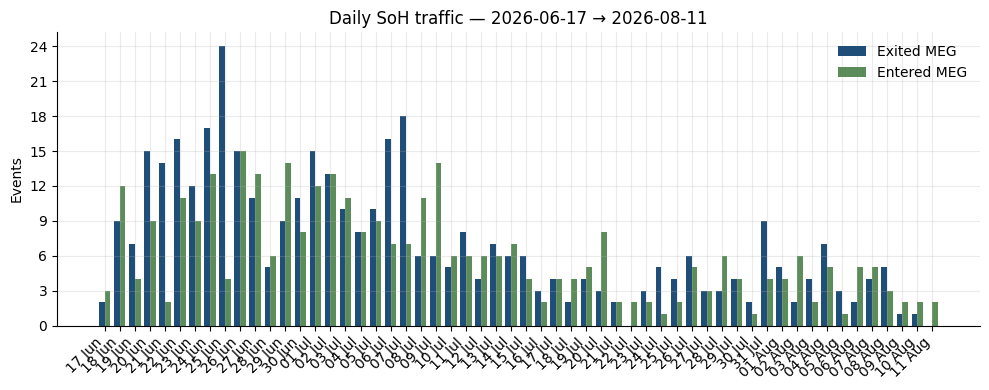

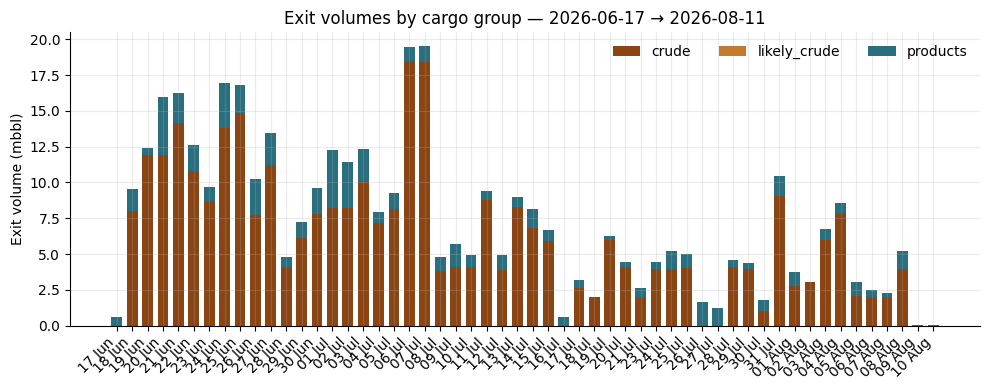

In [14]:
# Shared colors — one meaning per series across all charts.
COLORS = {
    "Exited MEG": "#1f4e79",
    "Entered MEG": "#5b8c5a",
    "crude": "#8b4513",
    "likely_crude": "#c47a2c",
    "products": "#2a6f7f",
    "ballast": "#8a8a8a",
    "unknown": "#b0b0b0",
    "other": "#6b6b6b",
    "Dark/Unknown Route": "#6b6b6b",  # route only — not "dark fleet"
    "Iranian Route": "#c47a2c",
    "Omani Route": "#2a6f7f",
    "IMO Route": "#5b8c5a",
    "dark fleet": "#a03c3c",
    "clean fleet": "#1f4e79",
}

period_label = f"{START_DATE} → {end}"


def _style_date_axis(ax):
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")


# --- 1) Daily traffic: exits vs entries ---
daily_counts = (
    period.assign(day=period["Crossing Date"].dt.normalize())
    .groupby(["day", "Direction"])
    .size()
    .unstack("Direction", fill_value=0)
    .sort_index()
)
for col in ["Exited MEG", "Entered MEG"]:
    if col not in daily_counts.columns:
        daily_counts[col] = 0

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(daily_counts))
width = 0.38
ax.bar(x - width / 2, daily_counts["Exited MEG"], width, label="Exited MEG", color=COLORS["Exited MEG"])
ax.bar(x + width / 2, daily_counts["Entered MEG"], width, label="Entered MEG", color=COLORS["Entered MEG"])
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%d %b") for d in daily_counts.index])
_style_date_axis(ax)
ax.set_ylabel("Events")
ax.set_title(f"Daily SoH traffic — {period_label}")
ax.legend(frameon=False)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
plt.show()

# --- 2) Exit volumes over time by cargo group ---
cargo_order = ["crude", "likely_crude", "products"]
vol_daily = (
    exited.assign(day=exited["Crossing Date"].dt.normalize())
    .groupby(["day", "cargo_group"])["volume_bbl"]
    .sum()
    .unstack("cargo_group", fill_value=0)
    .sort_index()
    / 1_000_000
)
for col in cargo_order:
    if col not in vol_daily.columns:
        vol_daily[col] = 0.0
vol_daily = vol_daily[cargo_order]

fig, ax = plt.subplots(figsize=(10, 4))
bottom = np.zeros(len(vol_daily))
x = np.arange(len(vol_daily))
for col in cargo_order:
    ax.bar(x, vol_daily[col], bottom=bottom, label=col, color=COLORS[col], width=0.7)
    bottom = bottom + vol_daily[col].to_numpy()
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%d %b") for d in vol_daily.index])
_style_date_axis(ax)
ax.set_ylabel("Exit volume (mbbl)")
ax.set_title(f"Exit volumes by cargo group — {period_label}")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()


## 10b. Exit volumes — dark vs clean by cargo

Same daily stacked-bar layout as the cargo-group chart above, split by cargo type and colored by **fleet** (dark = OFAC-sanctioned hulls; clean = not sanctioned). Re-run section 10 setup cell first if `COLORS` / `period_label` are missing.

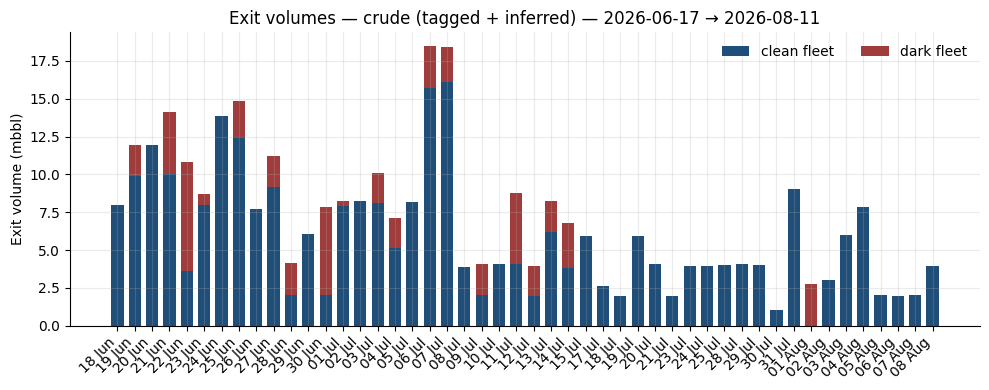

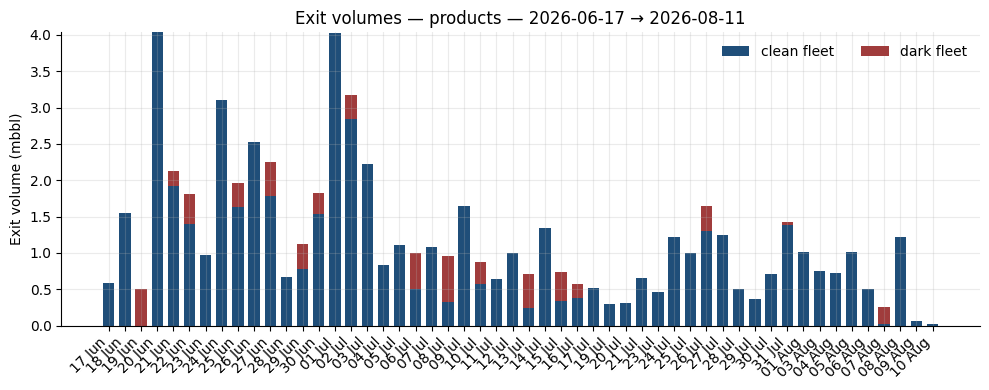

In [15]:
def _plot_exit_vol_by_fleet(df, *, title_suffix: str) -> None:
    """Daily exit volumes (mbbl), stacked by dark vs clean fleet."""
    fleet_order = ["clean fleet", "dark fleet"]
    vol_daily = (
        df.assign(day=df["Crossing Date"].dt.normalize())
        .groupby(["day", "fleet"])["volume_bbl"]
        .sum()
        .unstack("fleet", fill_value=0)
        .sort_index()
        / 1_000_000
    )
    for col in fleet_order:
        if col not in vol_daily.columns:
            vol_daily[col] = 0.0
    vol_daily = vol_daily[fleet_order]

    fig, ax = plt.subplots(figsize=(10, 4))
    bottom = np.zeros(len(vol_daily))
    x = np.arange(len(vol_daily))
    for col in fleet_order:
        ax.bar(x, vol_daily[col], bottom=bottom, label=col, color=COLORS[col], width=0.7)
        bottom = bottom + vol_daily[col].to_numpy()
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%d %b") for d in vol_daily.index])
    _style_date_axis(ax)
    ax.set_ylabel("Exit volume (mbbl)")
    ax.set_title(f"Exit volumes — {title_suffix} — {period_label}")
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    plt.show()


crude_exits = exited[exited["cargo_group"].isin(["crude", "likely_crude"])]
product_exits = exited[exited["cargo_group"] == "products"]

_plot_exit_vol_by_fleet(crude_exits, title_suffix="crude (tagged + inferred)")
_plot_exit_vol_by_fleet(product_exits, title_suffix="products")

## 10c. Exit volumes — cargo origin country

Same daily stacked-bar layout as 10b, colored by **`Last Cargo Country`** (cargo origin). Top origins by period volume are shown individually; the rest roll into **Other**. Re-run section 10 setup cell first if helpers are missing.

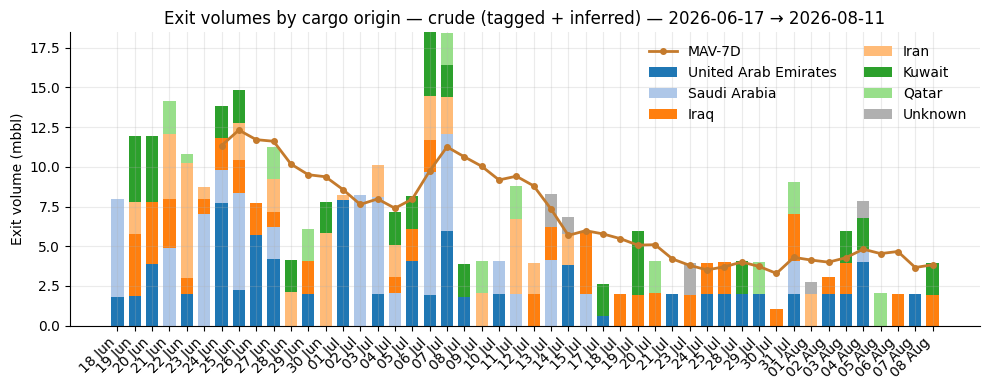

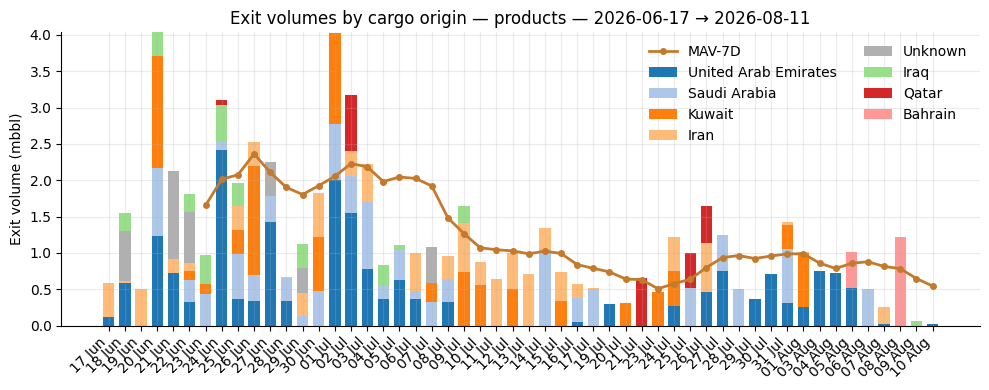

In [16]:
ORIGIN_TOP_N = 8


def _plot_exit_vol_by_origin(
    df, *, title_suffix: str, top_n: int = ORIGIN_TOP_N, ma_window: int = 7
) -> None:
    """Daily exit volumes (mbbl), stacked by last cargo country of origin."""
    plot_df = df.copy()
    plot_df["origin_country"] = (
        plot_df["Last Cargo Country"]
        .astype("string")
        .fillna("Unknown")
        .replace("", "Unknown")
    )

    country_totals = (
        plot_df.groupby("origin_country")["volume_bbl"].sum().sort_values(ascending=False)
    )
    top_countries = country_totals.head(top_n).index.tolist()
    plot_df["origin_bucket"] = np.where(
        plot_df["origin_country"].isin(top_countries),
        plot_df["origin_country"],
        "Other",
    )

    bucket_order = top_countries.copy()
    if (plot_df["origin_bucket"] == "Other").any():
        bucket_order.append("Other")

    vol_daily = (
        plot_df.assign(day=plot_df["Crossing Date"].dt.normalize())
        .groupby(["day", "origin_bucket"])["volume_bbl"]
        .sum()
        .unstack("origin_bucket", fill_value=0)
        .sort_index()
        / 1_000_000
    )
    for col in bucket_order:
        if col not in vol_daily.columns:
            vol_daily[col] = 0.0
    vol_daily = vol_daily[bucket_order]
    daily_total = vol_daily.sum(axis=1)
    daily_ma = daily_total.rolling(ma_window, min_periods=ma_window).mean()

    palette = list(plt.cm.tab20.colors)
    origin_colors = {
        country: palette[i % len(palette)] for i, country in enumerate(bucket_order)
    }
    origin_colors["Other"] = COLORS["other"]
    origin_colors["Unknown"] = COLORS["unknown"]

    fig, ax = plt.subplots(figsize=(10, 4))
    bottom = np.zeros(len(vol_daily))
    x = np.arange(len(vol_daily))
    for col in bucket_order:
        ax.bar(
            x,
            vol_daily[col],
            bottom=bottom,
            label=col,
            color=origin_colors.get(col, "#666"),
            width=0.7,
        )
        bottom = bottom + vol_daily[col].to_numpy()
    ax.plot(
        x,
        daily_ma.to_numpy(),
        color="#c47a2c",
        linewidth=2,
        marker="o",
        markersize=4,
        label=f"MAV-{ma_window}D",
        zorder=5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%d %b") for d in vol_daily.index])
    _style_date_axis(ax)
    ax.set_ylabel("Exit volume (mbbl)")
    ax.set_title(f"Exit volumes by cargo origin — {title_suffix} — {period_label}")
    ax.legend(frameon=False, ncol=2, loc="upper right")
    fig.tight_layout()
    plt.show()


crude_exits = exited[exited["cargo_group"].isin(["crude", "likely_crude"])]
product_exits = exited[exited["cargo_group"] == "products"]

_plot_exit_vol_by_origin(crude_exits, title_suffix="crude (tagged + inferred)")
_plot_exit_vol_by_origin(product_exits, title_suffix="products")

In [17]:
crude_exits.to_csv("exits.csv",index=False)

## 10d. Capacity pulse (entries / exits)

Daily **capacity kb** from AFRA-class lookup (VLCC / AFRA / LR2 defaults), with a 7-day moving average. Re-run section 10 setup cell first (`COLORS`, `_style_date_axis`, `period_label`).

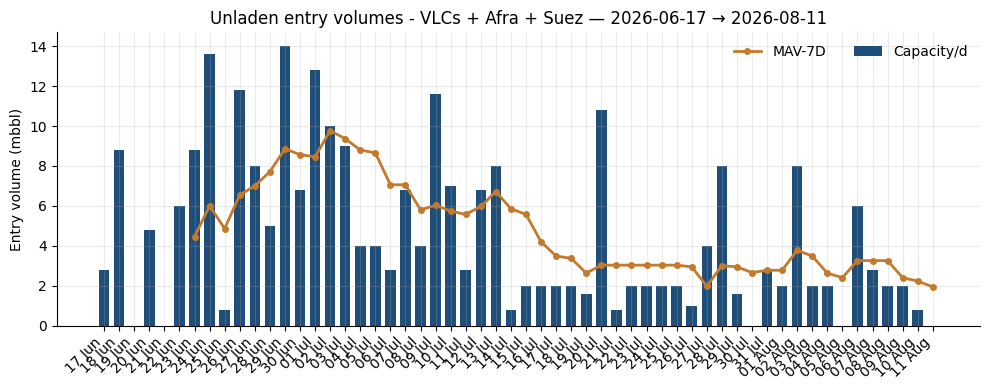

,capacity_mbbl,mav_7d_mbbl
day,,
2026-08-07,2.8,3.257143
2026-08-08,2.0,3.257143
2026-08-09,2.0,2.400000
2026-08-10,0.8,2.228571
2026-08-11,0.0,1.942857


In [18]:
# Nominal capacity per hull class (kb) — edit or pass class_capacity_kb= to the plot fn.
CLASS_CAPACITY_KB = {
    "VLCC": 2000,
    "AFRA": 800,
    "LR2": 1000,
}


def plot_capacity_pulse(
    df: pd.DataFrame | None = None,
    *,
    direction: str = "Entered MEG",
    sanctioned: bool | None = False,
    loading_state: str | None = "Ballast",
    afra_classes: list[str] | None = None,
    class_capacity_kb: dict[str, float] | None = None,
    ma_window: int = 7,
    title: str | None = None,
) -> pd.DataFrame:
    """
    Daily capacity (mbbl) bars + moving average. Input lookup stays in kb; chart divides by 1,000.

    Parameters
    ----------
    df : crossings slice; defaults to `period`.
    direction : 'Entered MEG' or 'Exited MEG'.
    sanctioned : False = clean only, True = sanctioned only, None = both.
    loading_state : 'Ballast', 'Laden', or None for all loading states.
    afra_classes : hull classes to include (default VLCC / AFRA / LR2).
    class_capacity_kb : kb per class; unmapped classes are dropped.
    ma_window : rolling-average window (days).
    """
    base = period if df is None else df
    capacity_map = CLASS_CAPACITY_KB if class_capacity_kb is None else class_capacity_kb
    classes = ["VLCC", "AFRA", "LR2"] if afra_classes is None else list(afra_classes)

    filtered = base.loc[base["Direction"].eq(direction)].copy()
    if sanctioned is not None:
        filtered = filtered.loc[filtered["sanctioned_any"].eq(sanctioned)]
    if loading_state is not None:
        filtered = filtered.loc[filtered["Loading State"].eq(loading_state)]
    filtered = filtered.loc[filtered["afra_class"].isin(classes)]

    filtered["capacity_kb"] = filtered["afra_class"].map(capacity_map)
    filtered = filtered.dropna(subset=["capacity_kb"])

    day_index = pd.date_range(pd.Timestamp(START_DATE), pd.Timestamp(end), freq="D")
    daily = (
        filtered.assign(day=filtered["Crossing Date"].dt.normalize())
        .groupby("day")["capacity_kb"]
        .sum()
        .reindex(day_index, fill_value=0.0)
        .sort_index()
    )
    daily_ma = daily.rolling(ma_window, min_periods=ma_window).mean()

    daily_mbbl = daily / 1_000
    daily_ma_mbbl = daily_ma / 1_000

    if title is None:
        title = "Unladen entry volumes - VLCs + Afra + Suez"

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(daily_mbbl))
    ax.bar(x, daily_mbbl.to_numpy(), color="#1f4e79", width=0.7, label="Capacity/d")
    ax.plot(
        x,
        daily_ma_mbbl.to_numpy(),
        color="#c47a2c",
        linewidth=2,
        marker="o",
        markersize=4,
        label=f"MAV-{ma_window}D",
    )
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%d %b") for d in daily_mbbl.index])
    _style_date_axis(ax)
    ax.set_ylabel("Entry volume (mbbl)")
    ax.set_title(f"{title} — {period_label}")
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    plt.show()

    out = pd.DataFrame(
        {"capacity_mbbl": daily_mbbl, f"mav_{ma_window}d_mbbl": daily_ma_mbbl}
    )
    out.index.name = "day"
    return out


# Default view: unsanctioned ballast VLCC / AFRA / LR2 entering SoH
capacity_daily = plot_capacity_pulse(
    sanctioned=False,
    loading_state="Ballast",
    afra_classes=["VLCC", "AFRA", "LR2"],
)
capacity_daily.tail()

In [19]:
period[(period['Direction'] == 'Entered MEG')&(period['Crossing Date'] >= '2026-07-12')].to_csv('entries.csv')

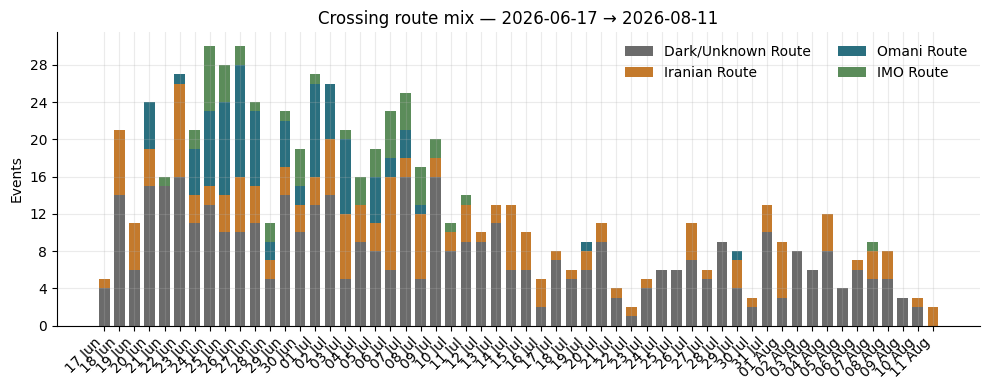

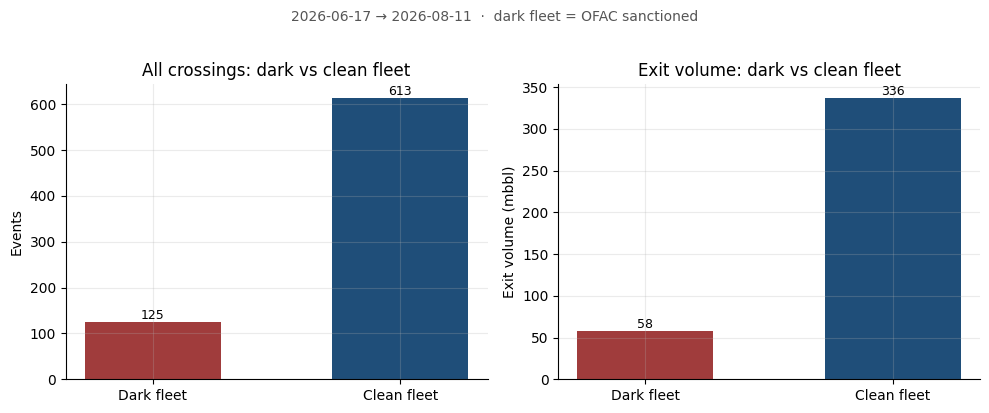

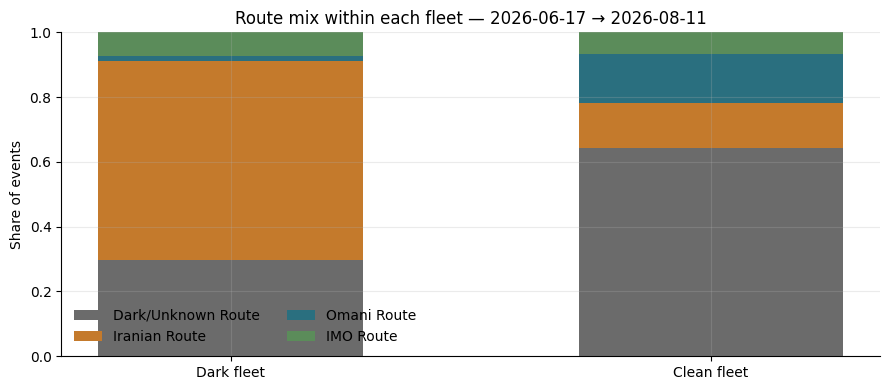

In [20]:
# --- 3) Route mix over time (route ≠ fleet) ---
route_order = ["Dark/Unknown Route", "Iranian Route", "Omani Route", "IMO Route"]
route_daily = (
    period.assign(day=period["Crossing Date"].dt.normalize())
    .groupby(["day", "Crossing Type"])
    .size()
    .unstack("Crossing Type", fill_value=0)
    .sort_index()
)
for col in route_order:
    if col not in route_daily.columns:
        route_daily[col] = 0
route_daily = route_daily[[c for c in route_order if c in route_daily.columns]]

fig, ax = plt.subplots(figsize=(10, 4))
bottom = np.zeros(len(route_daily))
x = np.arange(len(route_daily))
for col in route_daily.columns:
    ax.bar(x, route_daily[col], bottom=bottom, label=col, color=COLORS.get(col, "#666"), width=0.7)
    bottom = bottom + route_daily[col].to_numpy()
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%d %b") for d in route_daily.index])
_style_date_axis(ax)
ax.set_ylabel("Events")
ax.set_title(f"Crossing route mix — {period_label}")
ax.legend(frameon=False, ncol=2)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
plt.show()

# --- 4) Dark fleet vs clean fleet (sanctioned vs not) ---
fleet_order = ["dark fleet", "clean fleet"]
events_dc = period["fleet"].value_counts().reindex(fleet_order, fill_value=0)
vol_dc = (
    exited.groupby("fleet")["volume_bbl"].sum().reindex(fleet_order, fill_value=0) / 1_000_000
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, series, ylabel, title in [
    (axes[0], events_dc, "Events", "All crossings: dark vs clean fleet"),
    (axes[1], vol_dc, "Exit volume (mbbl)", "Exit volume: dark vs clean fleet"),
]:
    labels = ["Dark fleet", "Clean fleet"]
    vals = series.to_numpy()
    bars = ax.bar(
        labels,
        vals,
        color=[COLORS["dark fleet"], COLORS["clean fleet"]],
        width=0.55,
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.1f}" if ylabel.endswith("mbbl") else f"{int(val)}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
fig.suptitle(f"{period_label}  ·  dark fleet = OFAC sanctioned", y=1.02, fontsize=10, color="#555")
fig.tight_layout()
plt.show()

# Route mix within each fleet (are sanctioned hulls going dark-route?)
route_by_fleet = (
    period.groupby(["fleet", "Crossing Type"])
    .size()
    .unstack("Crossing Type", fill_value=0)
    .reindex(fleet_order)
)
route_by_fleet = route_by_fleet[[c for c in route_order if c in route_by_fleet.columns]]
route_share = route_by_fleet.div(route_by_fleet.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(route_share))
x = np.arange(len(route_share))
for col in route_share.columns:
    ax.bar(x, route_share[col], bottom=bottom, label=col, color=COLORS.get(col, "#666"), width=0.55)
    bottom = bottom + route_share[col].to_numpy()
ax.set_xticks(x)
ax.set_xticklabels(["Dark fleet", "Clean fleet"])
ax.set_ylabel("Share of events")
ax.set_ylim(0, 1)
ax.set_title(f"Route mix within each fleet — {period_label}")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


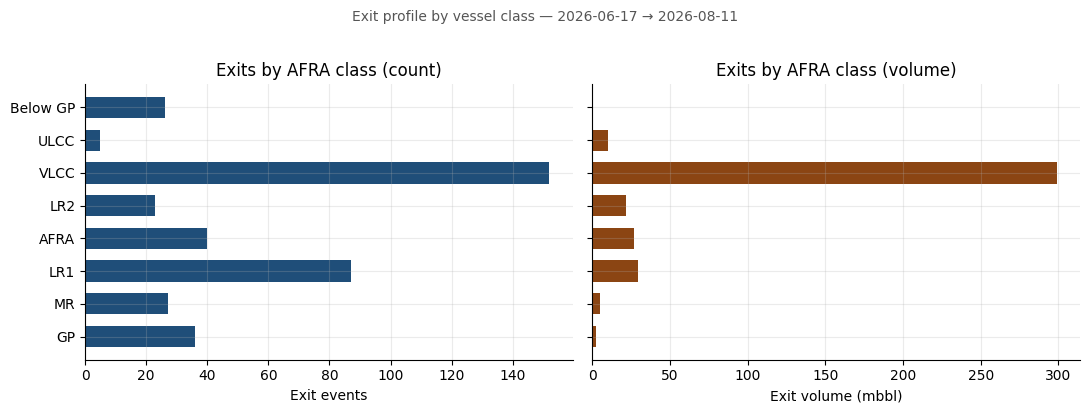

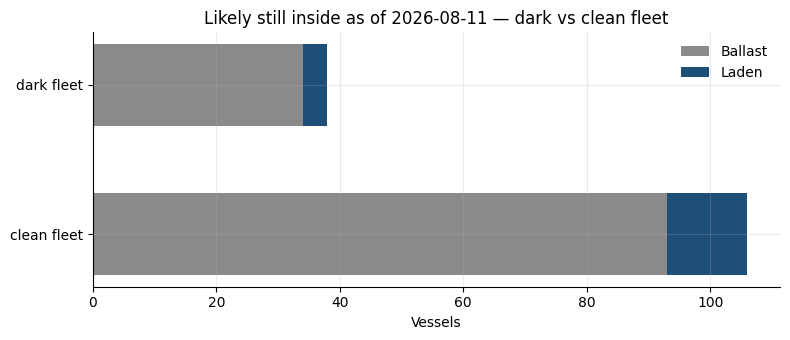

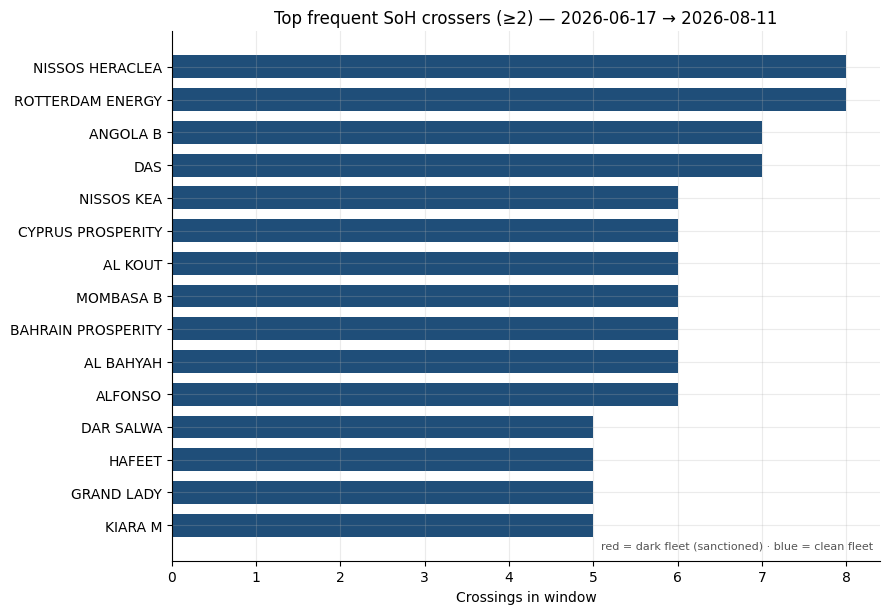

In [21]:
# --- 5) AFRA class of exits (volume + events) ---
afra_exits = (
    exited.groupby("afra_class", dropna=False)
    .agg(events=("IMO", "size"), volume_mbbl=("volume_bbl", lambda s: s.sum() / 1_000_000))
    .reindex(["GP", "MR", "LR1", "AFRA", "LR2", "VLCC", "ULCC", "Below GP", "Above ULCC"])
    .dropna(how="all")
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
y = np.arange(len(afra_exits))
axes[0].barh(y, afra_exits["events"], color="#1f4e79", height=0.65)
axes[0].set_xlabel("Exit events")
axes[0].set_title("Exits by AFRA class (count)")
axes[1].barh(y, afra_exits["volume_mbbl"], color="#8b4513", height=0.65)
axes[1].set_xlabel("Exit volume (mbbl)")
axes[1].set_title("Exits by AFRA class (volume)")
for ax in axes:
    ax.set_yticks(y)
    ax.set_yticklabels(afra_exits.index)
    ax.invert_yaxis()
fig.suptitle(f"Exit profile by vessel class — {period_label}", y=1.02, fontsize=10, color="#555")
fig.tight_layout()
plt.show()

# --- 6) Likely still inside: fleet × loading state ---
if len(likely_inside) == 0:
    print("No vessels flagged likely still inside for this window — skipping chart.")
else:
    inside_ct = (
        likely_inside.groupby(["fleet", "Loading State"])
        .size()
        .unstack("Loading State", fill_value=0)
    )
    for col in ["Ballast", "Laden"]:
        if col not in inside_ct.columns:
            inside_ct[col] = 0
    inside_ct = inside_ct.reindex(["dark fleet", "clean fleet"]).fillna(0)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    y = np.arange(len(inside_ct))
    ax.barh(y, inside_ct["Ballast"], height=0.55, label="Ballast", color=COLORS["ballast"])
    ax.barh(
        y,
        inside_ct["Laden"],
        height=0.55,
        left=inside_ct["Ballast"],
        label="Laden",
        color="#1f4e79",
    )
    ax.set_yticks(y)
    ax.set_yticklabels(inside_ct.index)
    ax.invert_yaxis()
    ax.set_xlabel("Vessels")
    ax.set_title(f"Likely still inside as of {as_of} — dark vs clean fleet")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

# --- 7) Top frequent crossers ---
top_n = 15
top_freq = frequent.head(top_n).iloc[::-1]
if len(top_freq) == 0:
    print(f"No vessels with ≥{MIN_CROSSINGS} crossings — skipping chart.")
else:
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(top_freq) + 1)))
    # Red = sanctioned (dark fleet); blue = clean.
    colors = [
        COLORS["dark fleet"] if bool(flag) else COLORS["clean fleet"]
        for flag in top_freq["is_dark_fleet"]
    ]
    ax.barh(top_freq["Vessel Name"], top_freq["crossings"], color=colors, height=0.7)
    ax.set_xlabel("Crossings in window")
    ax.set_title(f"Top frequent SoH crossers (≥{MIN_CROSSINGS}) — {period_label}")
    ax.text(
        0.99,
        0.02,
        "red = dark fleet (sanctioned) · blue = clean fleet",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="#555",
    )
    fig.tight_layout()
    plt.show()


## 11. One-shot period briefing

Compact text summary you can paste into a note / email.


In [22]:
def mbbl(x: float) -> str:
    return f"{x / 1_000_000:.2f} mbbl"


crude_bbl = crude_like["volume_bbl"].sum()
prod_bbl = products["volume_bbl"].sum()
dark_exit_bbl = exited.loc[exited["is_dark_fleet"], "volume_bbl"].sum()
clean_exit_bbl = exited.loc[~exited["is_dark_fleet"], "volume_bbl"].sum()

print(
    f"""SoH / MEG crossing briefing
Window: {START_DATE} → {end} (data through {data_max})

Traffic
  Exits:   {len(exited)} events / {exited['IMO'].nunique()} vessels
  Entries: {len(entered)} events / {entered['IMO'].nunique()} vessels
  Likely still inside as of {as_of}: {len(likely_inside)} vessels
    (entered since {START_DATE}; last observed event is still an entry)

Volumes out (exit events)
  Crude + likely_crude: {mbbl(crude_bbl)} ({crude_like['IMO'].nunique()} vessels)
  Products:             {mbbl(prod_bbl)} ({products['IMO'].nunique()} vessels)

Dark vs clean fleet (exit volume; dark fleet = OFAC sanctioned)
  Dark fleet: {mbbl(dark_exit_bbl)}
  Clean fleet: {mbbl(clean_exit_bbl)}

Dark fleet in window: {period.loc[period['is_dark_fleet'], 'IMO'].nunique()} vessels / {int(period['is_dark_fleet'].sum())} events
  of which Iran-list: {period.loc[period['sanctioned_iran'], 'IMO'].nunique()} vessels / {int(period['sanctioned_iran'].sum())} events
Frequent crossers (≥{MIN_CROSSINGS}): {len(frequent)} vessels
"""
)


SoH / MEG crossing briefing
Window: 2026-06-17 → 2026-08-11 (data through 2026-08-11)

Traffic
  Exits:   396 events / 330 vessels
  Entries: 342 events / 271 vessels
  Likely still inside as of 2026-08-11: 144 vessels
    (entered since 2026-06-17; last observed event is still an entry)

Volumes out (exit events)
  Crude + likely_crude: 332.03 mbbl (142 vessels)
  Products:             62.94 mbbl (157 vessels)

Dark vs clean fleet (exit volume; dark fleet = OFAC sanctioned)
  Dark fleet: 58.43 mbbl
  Clean fleet: 336.54 mbbl

Dark fleet in window: 87 vessels / 125 events
  of which Iran-list: 84 vessels / 121 events
Frequent crossers (≥2): 173 vessels



## Optional: yesterday-only quick filter

Uncomment and run if you want a one-day slice without changing the main config.
Uses the latest date present in the file (not calendar "today"), which is safer when the extract lags.

In [23]:
latest_day = crossings["Crossing Date"].max().normalize()
yday = in_period(crossings, start=latest_day, end=latest_day + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))
print(f"Latest data day: {latest_day.date()} — {len(yday)} events")
display(
    yday.groupby(["Direction", "Crossing Type", "fleet"])
    .agg(events=("IMO", "size"), volume_bbl=("volume_bbl", "sum"))
    .reset_index()
)


Latest data day: 2026-08-11 — 2 events


,Direction,Crossing Type,fleet,events,volume_bbl
0,Entered MEG,Iranian Route,clean fleet,2,0.0


In [24]:
latest_day + pd.Timedelta(days=-2)

Timestamp('2026-08-09 00:00:00')

In [25]:
yday

,Vessel Name,IMO,Vessel Classification,Flag Name,Direction,Crossing Date,Crossing Type,Loading State,Cargo Type,Quantity,Quantity Unit,Last Cargo Zone,Last Cargo Country,Next Port,Next Port Country,Deadweight,Build Year,Build Country,dwt_kdwt,afra_class,cargo_group,cargo_source,volume_bbl,sanctioned_iran,sanctioned_sdn,sanctioned_any,is_dark_route,is_dark_fleet,fleet
0,BLACK MAYA,9118800,Small Tankers,CURACAO,Entered MEG,2026-08-11,Iranian Route,Ballast,NaN,0,bbl,Muscat,Oman,Khor Al Zubair Port,Iraq,2005,"1,995",JAPAN,2.005,Below GP,ballast,loading_state,0.0,False,False,False,False,False,clean fleet
1,NEW FUTURE,9379313,MR,MARSHALL ISLANDS,Entered MEG,2026-08-11,Iranian Route,Ballast,NaN,0,bbl,Fujairah,United Arab Emirates,Hamriya,United Arab Emirates,50922,"2,007",REPUBLIC OF KOREA,50.922,LR1,ballast,loading_state,0.0,False,False,False,False,False,clean fleet
